
# Credit Card Customer Attrition Analysis

While credit cards are one of many banking products, understanding the relationship that demographic and behavior data have to them can be a very powerful tool. This understanding can assist in realigning consumer-facing product materials and can impact the effectiveness future campaigns. Insights generated from this data can be utilized across several different teams and vary in scope in an organization. This analysis is particularly relevant for professionals entering the banking industry who seek to work with real-world data scenarios.

### Scenario

A manager at the bank is concerned about increasing customer attrition from their credit card services. To address this, the current analysis examines customer data to identify key drivers of churn. Based on these insights, strategic next steps will be recommended to enable proactive outreach, improve services, and potentially reverse customers' decisions to leave. 

### About the Data

This dataset is a sample of credit card customer accounts starting in March 2013, where attrition has been defined as customers closing their credit card account within the following six months (April to October 2013). The sample includes a mix of snapshot data as of March 2013 and historical data covering the 12 months prior to March 2013, including demographic profiles and transaction information.

### Data Dictionary

This analysis utilizes the product table from "BankChurners.csv". The table is reproduced below for convenience:

| Field | Description |
|:---|:---|
| **CLIENTNUM** | Client number. Unique identifier for the customer holding the account |
| **Attrition_Flag** | Internal event (customer activity) variable - if the account is closed then 1 else 0 |
| **Customer_Age** | Demographic variable - Customer's Age in Years |
| **Gender** | Demographic variable - M=Male, F=Female |
| **Dependent_count** | Demographic variable - Number of dependents |
| **Education_Level** | Demographic variable - Educational Qualification of the account holder (example: high school, college graduate, etc.) |
| **Marital_Status** | Demographic variable - Married, Single, Divorced, Unknown |
| **Income_Category** | Demographic variable - Annual Income Category of the account holder (`Less than $40K`, `$40K-60K`, `$60K-$80K`,`$80K-$120K`, `greater than $120K`) |
| **Card_Category** | Product Variable - Type of Card (Blue, Silver, Gold, Platinum) |
| **Months_on_book** | Period of relationship with bank |
| **Total_Relationship_Count** | Total no. of products held by the customer |
| **Months_Inactive_12_mon** | No. of months inactive in the last 12 months |
| **Contacts_Count_12_mon** | No. of Contacts in the last 12 months |
| **Credit_Limit** | Credit Limit on the Credit Card |
| **Total_Revolving_Bal** | Total Revolving Balance on the Credit Card |
| **Avg_Open_To_Buy** | Open to Buy Credit Line (Average of last 12 months) |
| **Total_Amt_Chng_Q4_Q1** | Change in Transaction Amount (Q4 over Q1) |
| **Total_Trans_Amt** | Total Transaction Amount (Last 12 months) |
| **Total_Trans_Ct** | Total Transaction Count (Last 12 months)  |
| **Total_Ct_Chng_Q4_Q1** | Change in Transaction Count (Q4 over Q1) |
| **Avg_Utilization_Ratio** | The percentage of a customer's credit limit that they used (Average of least 12 months) |


## 1.0 - Import and Clean Data

To begin, the `pandas` and `matplotlib` libraries are imported, along with the `BankChurners.csv` file. These libraries are used to clean, manipulate, analyze, and visualize the dataset. Using pandas, a table is created in memory by assigning the DataFrame object to a variable named `bankchurners`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

bankchurners = pd.read_csv('/kaggle/input/datasets/sakshigoyal7/credit-card-customers/BankChurners.csv')

As requested by the dataset owner, the final two columns were excluded from the analysis and omitted from the data dictionary for improved readability. Based on the column titles, it appears the original owner may have intended to apply a specific Bayesian statistical approach; however, for the purposes of this analysis, these columns are not used. The `shape()` method is applied to confirm the remaining number of rows and columns in the DataFrame.

In [2]:
print('Starting number of columns -', bankchurners.shape[1])
columns_owner_asked_to_drop = [
  'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
  'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]

bankchurners.drop(columns_owner_asked_to_drop, axis=1, inplace=True)
print('Revised Total number of columns -', bankchurners.shape[1])
print('Rows -', bankchurners.shape[0])

Starting number of columns - 23
Revised Total number of columns - 21
Rows - 10127


With the final two columns removed, it's now appropriate to display `BankChurners.csv` dataset as a table. The `bankchurners` variable defined earlier is used to display the first ten rows. Note that the term "Unknown" appears throughout this dataset and will be addressed in a later section.

In [3]:
bankchurners.head(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,1,2,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,1,3,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,2,2,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,2,0,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,3,3,11656.0,1677,9979.0,1.524,1441,32,0.882,0.144



### 1.1 - Finding Null Values

Regardless of the perceived reliability of the `BankChurners.csv` file, a critical step is to verify data cleanliness and address any inconsistencies. To avoid complications during analysis, such as encountering unusable fields due to improper null handling, confirmation is performed using the `.isnull()` and `sum()` methods to quantify null values in each column.

In [4]:
nulls_by_column = pd.DataFrame(bankchurners.isnull().sum(), columns=['Number of Nulls'])
nulls_by_column

,Number of Nulls
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0



### 1.2 - Correcting Data Type Errors

Next, the appropriateness of each column's data type is evaluated. The `DataFrame` object and `dtypes` attribute are used to display this information.

In [5]:
pd.DataFrame(bankchurners.dtypes, columns=['Data Types'])

,Data Types
CLIENTNUM,int64
Attrition_Flag,object
Customer_Age,int64
Gender,object
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64


Since the "Credit_Limit" column typically represents whole numbers in business contexts, it is converted to an integer type for consistency. Unique values containing non-zero decimal places are listed to assess the scope of the discrepancy.

In [6]:
non_zero_decimal = bankchurners[bankchurners['Credit_Limit'] % 1 != 0]
unique_values = non_zero_decimal.Credit_Limit.unique()
print(unique_values)

[1438.3]


The results indicate that values with non-zero decimals consistently appear as "1438.3". For the "Credit_Limit" column, the `astype()` method is applied to truncate values to integers. The `round()` method was not selected, given that the decimal value is consistently "1438.3" and both rounding and truncation would yield the same integer result.

In [7]:
bankchurners['Credit_Limit'] = bankchurners.Credit_Limit.astype('int')

turned_into_int = bankchurners[bankchurners['Credit_Limit'] == 1438]
pd.DataFrame(turned_into_int.Credit_Limit.head())

,Credit_Limit
21,1438
51,1438
108,1438
169,1438
187,1438


Given that "CLIENTNUM" serves as a unique identifier, it is set as the DataFrame index.

In [8]:
bankchurners = bankchurners.set_index('CLIENTNUM')
bankchurners.head(1)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
CLIENTNUM,,,,,,,,,,,,,,,,,,,,
768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691,777,11914.0,1.335,1144,42,1.625,0.061



### 1.3 - Finding Duplicate Rows

Using the "CLIENTNUM" identifiers, duplicate entries are checked to ensure data integrity. This prevents duplicate records from affecting future aggregate calculations. The `index` attribute is examined, as "CLIENTNUM" was previously set as the index.

In [9]:
duplicate_rows = bankchurners.index.duplicated().sum()
print(f'Total duplicate CLIENTNUM Rows: {duplicate_rows}')

Total duplicate CLIENTNUM Rows: 0



#### 1.4 - Finding "Unknown" Placeholder Values

Previously, it was determined that no null values exist in this dataset, and the data types for each column were verified. While this is good, the data validation process is not yet complete. 

It is known that the previous owner replaced null values with the string "Unknown". To ensure awareness, a `for` loop is implemented to iterate through columns and identify any instances of the "Unknown" placeholder using `if` conditional statements.

In [10]:
print('\n=== UNKNOWN VALUES ===')
for col in bankchurners.columns: 
# identify column names in loop of columns
  if bankchurners[col].dtype == 'object': 
  # find datatype in column and confirm it's an object/string
    count = (bankchurners[col] == 'Unknown').sum() 
    # if it is an object/string sum the "Unknown" values
    if count: 
    # if a sum was made
      print(f'{col}: {count}') 
      # include the column name and sum of unkown when printing the result


=== UNKNOWN VALUES ===
Education_Level: 1519
Marital_Status: 749
Income_Category: 1112



## 2.0 - Calculations & Dry Code

To address customer churn as requested by the bank manager, calculations are performed to determine the churn rate. According to the data dictionary, the "Attrition_Flag" column is defined as customers closing their credit card account 6 months after the rest of dataset was collected. Since this column represents a time-based metric, churn rate can be calculated through dividing the number of attrited customers by the total number of customers. Rows (also known as entries) are used to represent the total number of customers, as each CLIENTNUM identifier is unique.

In [11]:
attrition_flag_counts = bankchurners['Attrition_Flag'].value_counts()
# Count "Exisiting Customers" and "Attrited Customers" values in "Attrition_Flag" column
churn_rate = (attrition_flag_counts['Attrited Customer']/bankchurners.shape[0]*100).round(2) 
# Use count of "Attrited Customers" over total number of rows/customers to determine rate
print(pd.DataFrame(attrition_flag_counts))
# Print "Exisiting Customers" and "Attrited Customers" count
print(f"\nChurn rate: {churn_rate}%") 
# Print churn rate

                   count
Attrition_Flag          
Existing Customer   8500
Attrited Customer   1627

Churn rate: 16.07%


Although the churn rate has been identified as **16.07%**, attrited customers are further separated from existing customers for additional analysis. A new column named "Is_Attrited" is created to facilitate future calculations.

In [12]:
bankchurners['Is_Attrited'] = bankchurners['Attrition_Flag'] == 'Attrited Customer' 
# Creating a new boolean column called "Is_Attrited" 
pd.DataFrame(bankchurners['Is_Attrited'].tail())
# Using tail simply since it shows both "true" and "false" values

,Is_Attrited
CLIENTNUM,
772366833,False
710638233,True
716506083,True
717406983,True
714337233,True


With the "Is_Attrited" column established, churn rate can be calculated and visualized using the `mean()` method. To streamline visualization code, a reusable function is created for generating charts. This approach simplifies visualization creation, as only a DataFrame variable with the appropriately grouped column needs to be passed to the function.

In [13]:
def calc_churn_rate(dataframe_grouped, sort_ascending=True): 
# Create function parameters that takes a grouped dataframe variable, defaults sort ascending to "True" unless an input is provided
    result = dataframe_grouped[['Is_Attrited']] \
        .mean() \
        .multiply(100) \
        .rename(columns={'Is_Attrited': 'Churn Rate'}) \
        .round(2) \
        .sort_values('Churn Rate', ascending=sort_ascending)  
    # Create local variable called result that takes grouped dataframe
        # Calculates churn rate with mean()
        # Multiplies the rate by 100
        # Renames the "Is_Attrited" chart legend to "Churn Rate"
        # Round result to two decimal places
        # Sort values in ascending order unless alternate input is used
    return result
    # returns local variable called result for the function


## 3.0 - Visualizations

Visualizations are examined to understand the bank manager's concern and provide actionable suggestions. Providing them to the manager will allow analysts to defend actions necessary to improve products. It will also make it easier to identify factors that contribute to higher churn rate.

### 3.1 - Churn Rate by Card Type

The first visualization examines credit card products themselves. Churn rate is compared across card types, providing a logical starting point given the manager's focus on credit card customer retention.

In [14]:
cards_grouped = bankchurners.groupby('Card_Category')
churn_by_card = calc_churn_rate(cards_grouped)
churn_by_card.index.name = 'Card Type'
churn_by_card

,Churn Rate
Card Type,
Silver,14.77
Blue,16.10
Gold,18.10
Platinum,25.00


Notably, both "Gold" and "Platinum" cards exhibit churn rates above the average of 16.07%, shown with the red dotted line. While "Blue" cards also exceed the average, the deviation is less pronounced.

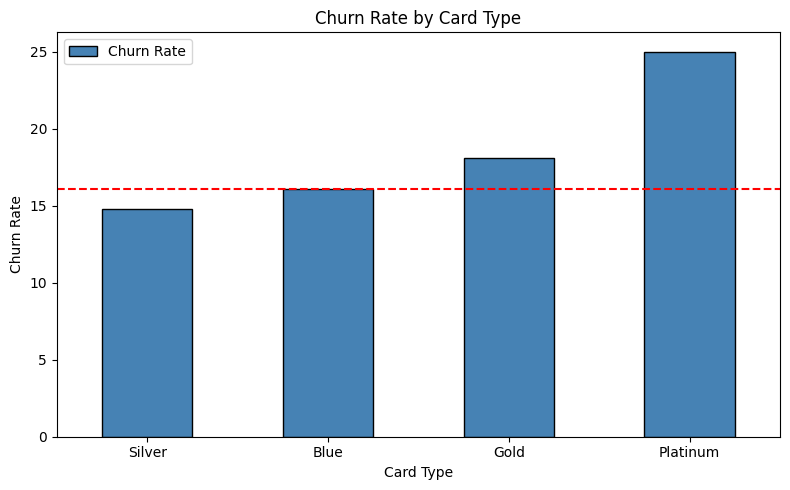

In [15]:
churn_by_card.plot(kind='bar', figsize=(8, 5), color='steelblue', edgecolor='black')

plt.title('Churn Rate by Card Type')
plt.axhline(y=16.07, color='red', linestyle='--')
plt.xlabel('Card Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout();

> **Insights:** When evaluating product features, the bank manager should consider examining the features offered by "Gold" and "Platinum" cards to understand why customers using these products churn at higher rates.

### 3.2 - Education Level by Churn Rate

Demographic data, specifically customer education level, is analyzed next. This information can help the bank manager focus future campaigns on specific target audiences. "Unknown" values are excluded from the visualization to facilitate clearer identification of actionable dimensions.

In [16]:
education_grouped = bankchurners[bankchurners['Education_Level'] != 'Unknown'].groupby('Education_Level')
churn_by_education = calc_churn_rate(education_grouped)
churn_by_education.index.name = 'Education Lvl'
churn_by_education

,Churn Rate
Education Lvl,
College,15.20
High School,15.20
Graduate,15.57
Uneducated,15.94
Post-Graduate,17.83
Doctorate,21.06


The analysis reveals that customers with "Post-Graduate" and "Doctorate" education levels exhibit churn rates well past the average, again shown with the red dotted line. This finding presents an opportunity for targeted advertising material.

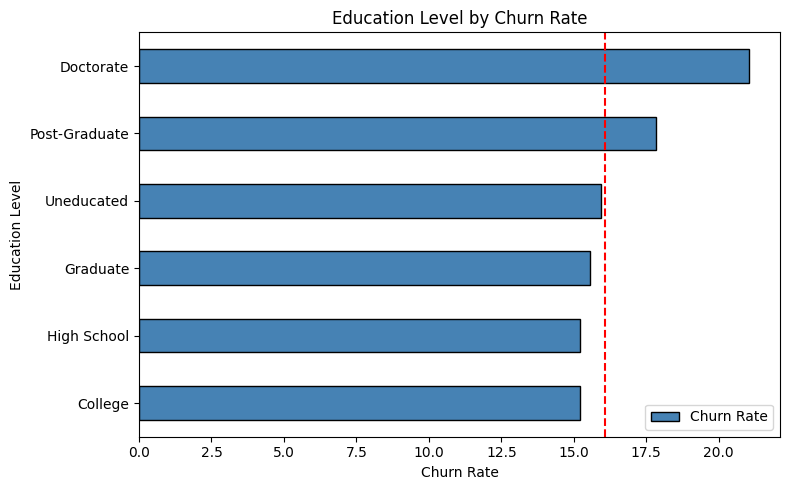

In [17]:
churn_by_education.plot(kind='barh',figsize=(8, 5), color='steelblue', edgecolor='black')

plt.title('Education Level by Churn Rate')
plt.axvline(x=16.07, color='red', linestyle='--')
plt.xlabel('Churn Rate')
plt.ylabel('Education Level')
plt.tight_layout();

> **Insights:** Highly educated customers are more likely to leave. New campaign materials should be developed to cater to this demographic. This also suggests an opportunity to provide enhanced rewards for customers holding Post-Graduate or Doctorate qualifications.

### 3.3 - Transaction Count by Customer Status

Customer behavior regarding card usage is examined to connect findings from the previous visualizations. A boxplot is used, requiring the "Is_Attrited" column to be separated into two categories to compare transaction counts between "Existing" and "Attrited" customers.

In [18]:
attrited_transaction_ct = pd.DataFrame({
  'Existing': bankchurners[bankchurners['Is_Attrited'] == False]['Total_Trans_Ct'],
  'Attrited': bankchurners[bankchurners['Is_Attrited'] == True]['Total_Trans_Ct']
})

print("\n\nTRANSACTION COUNT")
attrited_transaction_ct.describe().round(2)



TRANSACTION COUNT


,Existing,Attrited
count,8500.00,1627.00
mean,68.67,44.93
std,22.92,14.57
min,11.00,10.00
25%,54.00,37.00
50%,71.00,43.00
75%,82.00,51.00
max,139.00,94.00


The results indicate that attrited customers use their cards less frequently with an average 45 uses, which approximately 35% fewer transactions. Also, shows two clear groups forming, with attrited having a max of 94 uses, which is 32% less than exisiting customers.

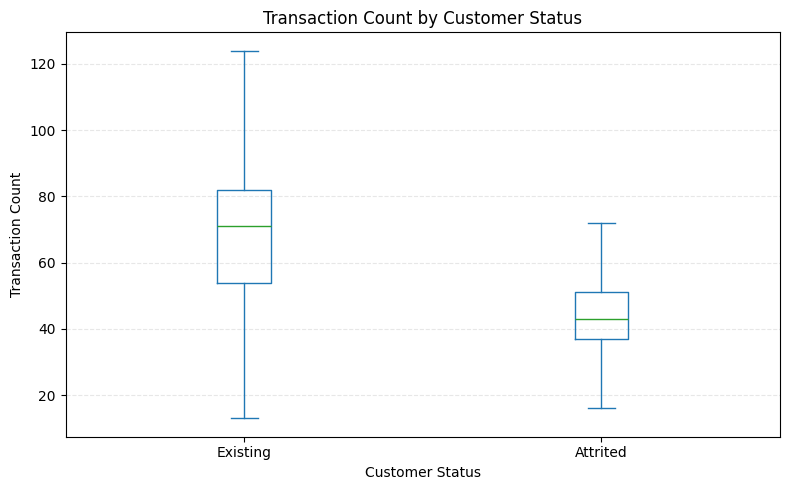

In [19]:
attrited_transaction_ct.plot(kind='box', figsize=(8, 5), showfliers=False, title='Transaction Count by Customer Status')

plt.ylabel('Transaction Count')
plt.xlabel('Customer Status')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout();

> **Insights:** Consumer engagement with their card is a significant factor. This supports the recommendation of offering rewards to encourage increased card usage. Incentives for customers to use their cards more frequently should be considered.

### 3.4 - Transaction Amount and Count by Customer Status

Given that transaction frequency plays a significant role in customer attrition, transaction amounts are also analyzed to determine if spending behavior is a contributing factor.

In [20]:
attrited_transaction_amt = pd.DataFrame({
  'Existing': bankchurners[bankchurners['Is_Attrited'] == False]['Total_Trans_Amt'],
  'Attrited': bankchurners[bankchurners['Is_Attrited'] == True]['Total_Trans_Amt']
})

print("\n\nTRANSACTION AMOUNT")
attrited_transaction_amt.describe().round(2)



TRANSACTION AMOUNT


,Existing,Attrited
count,8500.00,1627.00
mean,4654.66,3095.03
std,3512.77,2308.23
min,816.00,510.00
25%,2384.75,1903.50
50%,4100.00,2329.00
75%,4781.25,2772.00
max,18484.00,10583.00


Additional insights emerge from this analysis. The minimum amount spent by attrited customers is approximately 38% lower compared to existing customers. Data indicates that customers who spend less than 816 dollars in a 12-month period consistently exhibit attrition, identifying this group as highest risk. Within the 75th percentile, attrited customers who spend less than 2,772 dollars or use their card fewer than 51 times are also at elevated risk of leaving the bank.

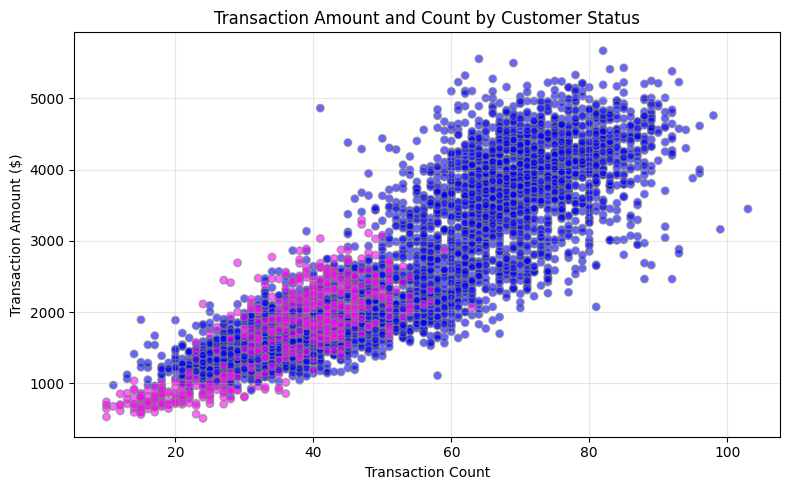

In [21]:
sample_bankchurners = bankchurners.head(5000).copy()
sample_bankchurners['Churn_Color'] = sample_bankchurners['Is_Attrited'].map({
  True: 'magenta', 
  False: 'blue'
})

sample_bankchurners.plot(kind='scatter', x='Total_Trans_Ct', y='Total_Trans_Amt', c='Churn_Color', edgecolors='gray', alpha=0.6, s=30, figsize=(8, 5),
  title='Transaction Amount and Count by Customer Status'
)

plt.xlabel('Transaction Count')
plt.ylabel('Transaction Amount ($)')
plt.grid(alpha=0.3)
plt.tight_layout();


## 4.0 - Summary of Key Findings

Let's highlight the important points:
* Overall churn rate: **16.07%**
* High risk segments: **Highly Educated customers**, along with **Gold** and **Platinum** card users
* High risk behavior: Spend less than **\$2772**, use the card fewer than **51 times** over 12 months (about once a week)
* Highest risk behavior: Spend less than **\$816**, use the card fewer than **37 times** over 12 months

Based on these insights, it is recommended that the bank manager pivot targeting efforts toward customers with higher education levels through channels such as social media, paid advertising, and sponsorship opportunities. Card features should be updated to include rewards tailored to this demographic; consider limiting these enhanced rewards to Gold and Platinum cards. This approach would serve two primary objectives: attracting new highly educated customers and encouraging existing customers within this demographic to increase spending. Promoting this behavior is likely to be a critical factor in retaining these customers.

Finally, retention strategies should be implemented for customers who spend the least and use their cards infrequently. Common retention tactics leverage existing communication channels, including email, text messaging, and direct mail. These channels can be used to incentivize highest-risk customers through targeted discounts and educational content designed to improve confidence in card usage.